In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import ast
import ipywidgets as widgets
from IPython.display import display, clear_output

In [ ]:
csv = pd.read_csv('director_list.csv')

def loading_data(csv):
    """
    Loads and preprocesses data

    Parameters:
    - csv: pandas DataFrame containing dataset

    Return:
    - result: DataFrame containing historical and newest scores for each director
    """
    data = csv.copy()


    results = []

    # Going through all directors
    for i in range(len(data)):
        # Reading director specific movies
        df = pd.read_csv(f"director_{i}.csv")

        # sort movies by year
        df = df.sort_values('release_year')
        # latest movie
        latest = df.iloc[-1]

        # historical movies
        historical = df.iloc[:-1]

        # Calculating overall mean score of the different factors for all movies before the last one 
        hist_avg_score = historical["avg_score"].mean()
        hist_avg_roi  = (historical['revenue'] / historical['budget']).mean()
        hist_avg_revenue = historical['revenue'].mean()
        hist_votes = historical['imdb_vote_count'].sum()

        # Getting the scores for the latest movie
        new_score = latest['avg_score']
        new_roi = latest['revenue']/latest['budget']
        new_revenue = latest['revenue']
        new_votes = latest['imdb_vote_count']

        # Adding entry to result dictionary for each director
        results.append({
            'director' : data['name'][i],
            'hist_avg_score' : hist_avg_score,
            'hist_avg_roi' : hist_avg_roi,
            'hist_avg_revenue' : hist_avg_revenue,
            'hist_total_votes' : hist_votes,
            'new_score' : new_score,
            'new_roi' : new_roi,
            'new_revenue' : new_revenue,
            'new_votes' : new_votes 
        })

    analysis_df = pd.DataFrame(results)

    corr = analysis_df.corr(numeric_only=True)

    return analysis_df

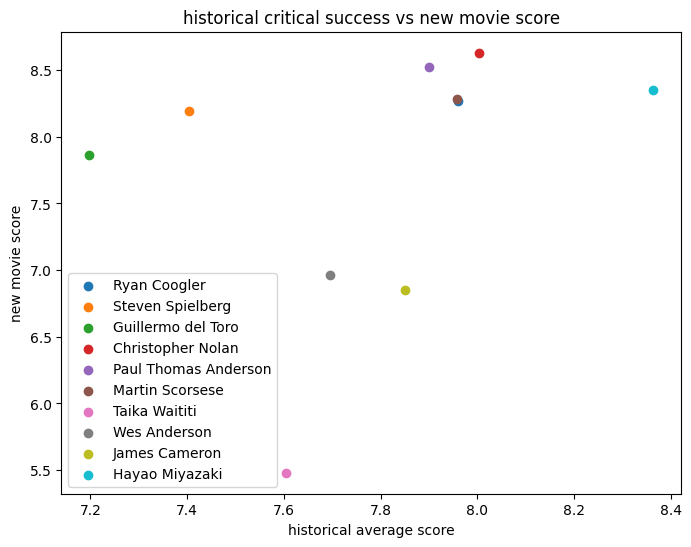

In [ ]:
def avg_score_scatter(csv):
    """
    Plots average historical score with newest movie score per director on scatter chart

    Parameters:
    - csv: pandas DataFrame containing the dataset
    """
    data = loading_data(csv.copy())

    # Setting size of the graph
    plt.figure(figsize=(8,6))

    # Going through result director list
    for i, director in enumerate(data['director']):
        # Plotting the average_score comparison for each director
        plt.scatter(data['hist_avg_score'][i], data['new_score'][i],
                    marker='o',
                    label=director

                    )
        plt.text(
            data['hist_avg_score'][i],
            data['new_score'][i],
            ""
        )

    plt.xlabel('historical average score')
    plt.ylabel('new movie score')
    plt.title('historical critical success vs new movie score')

    plt.legend()
    
    plt.show()

avg_score_scatter(csv)

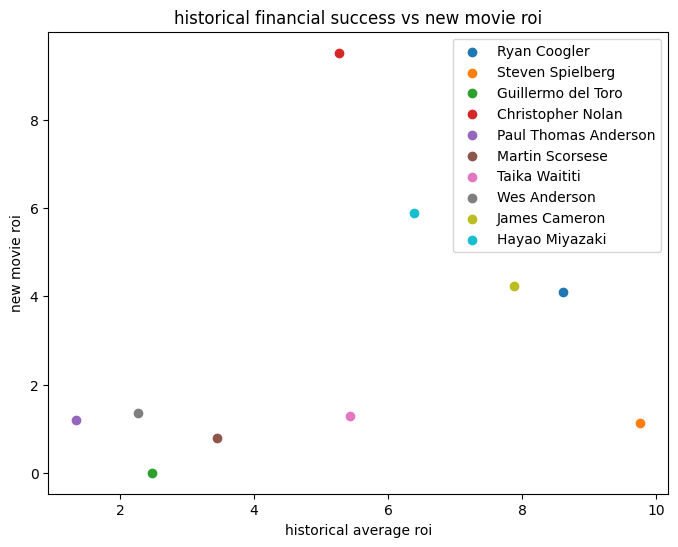

In [ ]:
def financial_success_scatter(csv):
    """
    Plotting average historical Return of Invest with newest movie's Return of Invest per director

    Parameters: 
    - csv: pandas DataFrame containing the dataset
    """
    data = loading_data(csv)
    plt.figure(figsize=(8,6))

    # Going through director list
    for i, director in enumerate(data['director']):
        
        # Plot each director's historic average ROI with their newest movie's ROI
        plt.scatter(data['hist_avg_roi'][i], data['new_roi'][i],
                    marker='o',
                    label=director
                    )
        plt.text(
            data['hist_avg_roi'][i],
            data['new_roi'][i],
            ""
        )

    plt.xlabel('historical average roi')
    plt.ylabel('new movie roi')
    plt.title('historical financial success vs new movie roi')
    plt.legend()
    plt.show()

financial_success_scatter(csv)

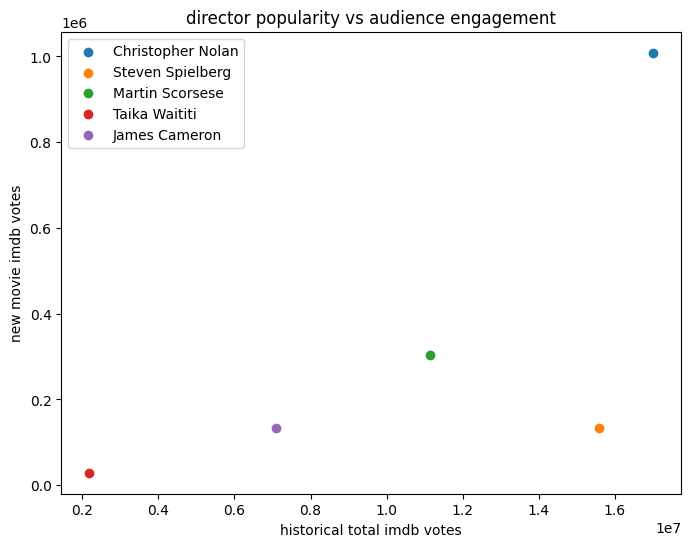

In [ ]:
def popularity_scatter(csv):
    """
    Plotting total historic IMDb votes per director with their newest movie's IMDb votes

    Parameters:
    - csv: pandas DataFrame containing the dataset
    """
    data = loading_data(csv)

    plt.figure(figsize=(8,6))

    # Going through each director
    for i, director in enumerate(data['director']):
        # Plotting the historic total IMDb vote count per director with their newest movie's IMDb vote count
        plt.scatter(data['hist_total_votes'][i], data['new_votes'][i],
                marker='o',
                label=director
                )


        plt.text(
            data['hist_total_votes'][i],
            data['new_votes'][i],
            ""
        )
        
    plt.xlabel('historical total imdb votes')
    plt.ylabel('new movie imdb votes')
    
    plt.title('director popularity vs audience engagement')

    plt.legend()
    plt.show()

popularity_scatter(csv)

In [ ]:
def load_and_clean_director_data(director_ids):
    """
    Loads and cleans data for director career timeline

    Parameters:
    - director_ids : list of ID's for each director chosen to be shown

    Return:
    - data : dictionary of pandas DataFrames containing data for each chosen director
    """

    data = {}

    for i in director_ids:
        df = pd.read_csv(f"director_{i}.csv")

        # Ensure numeric types and any errors become NaN
        df = df.copy()
        df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
        df['avg_score'] = pd.to_numeric(df['avg_score'], errors='coerce')
        
        # Remove rows with missing key values
        df = df.dropna(subset=['release_year','avg_score'])
        
        # Sort values by release year
        df = df.sort_values('release_year')

        data[i] = df

    return data

In [ ]:
def plot_director_careers(csv, director_ids):
    """
    Plots directors career performances for selected directors over time, showing average movie scores by release year
    
    Parameters:
    - csv: pandas DataFrame containing the main dataset
    - director_ids: list of chosen director IDs 
    """

    data= loading_data(csv)

    dfs = load_and_clean_director_data(director_ids)

    plt.figure(figsize=(12,6))
    
    # Going through each chosen director
    for director_id, df in dfs.items():
        # Plotting average score over release years for each chosen director
        plt.plot(
            df['release_year'],
            df['avg_score'],
            marker='o',
            label=data['director'][director_id]
        )
    
    plt.xlabel('release year')
    plt.ylabel('average score')

    plt.title('director career critical performance over time')

    plt.legend()

    plt.grid(True, alpha=0.3)
    
    plt.show()



In [ ]:
def director_over_time_plot(data):
    """
    Interactive widget (checkboxes) to select directors and plot their careers over release years

    Paremeters:
    - data: pandas DataFrame containing main dataset
    """

    # Output widget to display the plot
    output = widgets.Output()
    # Creating list of director indices (used as IDs)
    director_ids = list(range(0,len(data)))

    # Creating checkboxes for each director
    checkboxes = [widgets.Checkbox(value=True, description=data['director'][i]) for i in director_ids]

    def update_plot(change=None):
        """
        Callback function that's triggered when any checkboxes value changes and updates plot with chosen checkboxes
        """
        
        # Collect ID's of selected directors
        selected = [i for i, cb in enumerate(checkboxes) if cb.value]

        # Update the output
        with output:
            clear_output(wait=True)

            if selected:
                plot_director_careers(selected)
    
    # Connecting update function to each checkbox 
    for cb in checkboxes:
        cb.observe(update_plot, names='value')

    display(widgets.VBox(checkboxes)) # Show all checkboxes
    display(output) # Show output

    update_plot()
    
director_over_time_plot(loading_data(csv))

Output()

In [ ]:
def load_director_score_matrix(csv, director_ids):
    """
    Loads and cleans data for director career timeline into matrix for heatmap

    Parameters:
    - csv : pandas DataFrame containing main dataset
    - director_ids : list of ID's for each director chosen to be shown

    Return:
    - matrix : pandas DataFrame (pivot table)
                rows = directors
                columns = release years
                value = average scores
    """
    data = loading_data(csv)

    dfs = []

    # Going through chosen directors
    for i in director_ids:

        df = pd.read_csv(f'director_{i}.csv')

        # Ensuring numeric types and setting errors to NaN
        df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
        df['avg_score'] = pd.to_numeric(df['avg_score'], errors='coerce')

        # Removing rows with missing key values
        df = df.dropna(subset=['release_year', 'avg_score'])

        # Add a colmun identifying the director using their names
        df['director_id'] = data['director'][i]

        dfs.append(df)

    # Combine all director DataFrames into one
    combined = pd.concat(dfs)

    # Creating pivot table with rows being directors, columns being release years and values being the average scores
    matrix = combined.pivot_table(
        index = 'director_id',
        columns = 'release_year',
        values = 'avg_score',
        aggfunc = 'mean'
    )
    return matrix

In [ ]:
def plot_director_heatmap(director_ids):
    """
    Plotting director's career timelines with average score over heatmap

    Parameters:
    - director_ids: list of ID's of chosen directors
    """
    matrix = load_director_score_matrix(director_ids)
    
    plt.figure(figsize=(14,6))
    
    # Display matrix as image, that automatically adjusts the size and has the Red to Green colorpalet
    plt.imshow(matrix, aspect='auto', cmap='RdYlGn')

    # Add colobar to indicate score scale
    plt.colorbar(label='average score')

    # Set y-axis ticks to be each director
    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )

    # Set x-axis ticks to be one per year
    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=45
    )

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

In [ ]:
def director_over_time_heatmap(data):
    """
    Interactive widget (checkboxes) to select directors and show their careers over release years on a heatmap

    Paremeters:
    - data: pandas DataFrame containing main dataset
    """

    # Output widget where heatmap will be shown
    output = widgets.Output()

    # Create list of director IDs
    director_ids=list(range(len(data)))


    # Create a checkbox for each director
    checkboxes = [widgets.Checkbox(value=True, description=data['director'][i]) for i in director_ids]

    def update_heatmap(change=None):
        """
        Callback function triggered when a checkboxes value is changed and updates the heatmap
        """

        # Collect indices of selected directors
        selected = [i for i, cb in enumerate(checkboxes) if cb.value]

        # Update output area
        with output:
            clear_output(wait=True)

            if selected:
                plot_director_heatmap(selected)
            else:
                print('select at least one director')

    # Attach update function to each checkbox
    for cb in checkboxes:
        cb.observe(update_heatmap, names = 'value')
    
    display(widgets.VBox(checkboxes)) # Show checkboxes
    display(output) # Show output

    update_heatmap()

director_over_time_heatmap(loading_data(csv))

Output()

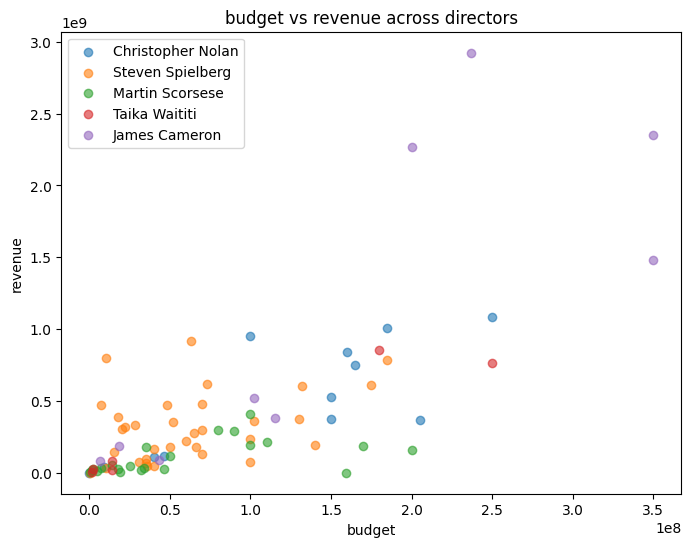

In [ ]:
def budget_revenue(csv):
    """
    Plots average historical budget vs revenue for each movie of each director

    Parameters: 
    - csv : pnadas DataFrame consisting of main dataset
    """
    data = loading_data(csv)
    plt.figure(figsize=(8,6))

    # Going through each director
    for i in range(0,len(data)):
        # Reading each dataset containing all movies for each director
        df = pd.read_csv(f'director_{i}.csv')
        
        # Plotting all movies revenue over budget for each director on scatterplot
        plt.scatter(df['budget'], df['revenue'], alpha=0.6, label=data['director'][i])

    plt.xlabel('budget')
    plt.ylabel('revenue')
    plt.title('budget vs revenue across directors')

    plt.legend()
    plt.show()

budget_revenue(csv)

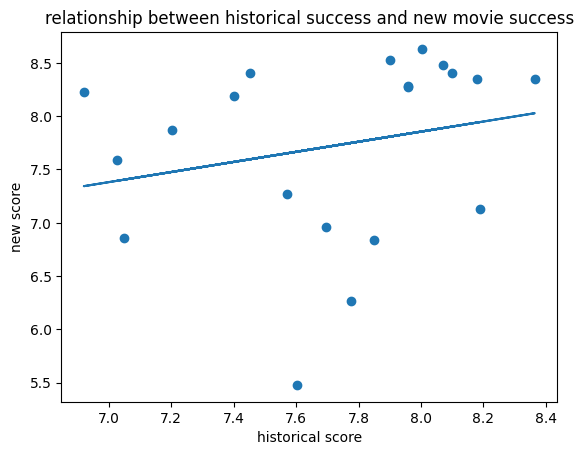

In [ ]:
def historical_new_success(csv):
    """
    Plot the relationship between a director's historical average score and their new movie score, including a fitted regression line

    Parameters:
    - csv: pandas DataFrame consisting of main dataset
    """
    data= loading_data(csv)

    # Extracting variables
    x = data['hist_avg_score'] # independent variable
    y= data['new_score']    # dependent variable

    # Make linear regression line
    m, b = np.polyfit(x,y,1)

    # Scatter plot of actual data points
    plt.scatter(x,y)    
    # Plot regression line
    plt.plot(x, m*x + b)

    plt.xlabel('historical score')
    plt.ylabel('new score')
    plt.title('relationship between historical success and new movie success')

    plt.show

historical_new_success(csv)